# Improved ResNet for Time Series Classification
## Improving Wang, Yan & Oates (2016)

---

### Areas for improvement in the original ResNet reproduction

| # | Issues | Fix |
|---|-------|-----|
| 1 | **Conv2D on (T,1,1)** but paper describes 1D convolutions | Rewrite with Conv1D |
| 2 | **Three residual blocks hardcoded** (90+ lines copy-paste) | Parameterised function |
| 3 | **Extra BatchNorm on input** — not in the paper | Removed |
| 4 | Code duplicated per dataset | Modular pipeline |
| 5 | Float batch_size, fragile label encoding | Integer `//`, LabelEncoder |
| 6 | Only `np.random.seed` | Seed all RNGs |
| 7 | No early stopping; min training loss selection | Early stopping on `val_loss` |
| 8 | `ReduceLROnPlateau` monitors training loss | Monitor `val_loss` |
| 9 | No GPU/MPS detection | Auto-detect + mixed precision |
| 10 | No dropout or regularisation (paper notes overfitting) | SpatialDropout + L2 |

In [1]:
pip install aeon

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings
import time
import logging
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

# GPU / MPS detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected       : {[g.name for g in gpus]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision    : enabled (float16)")
    except Exception:
        print("Mixed precision    : not available")
else:
    print("GPU detected       : None (using CPU)")

I0000 00:00:1775584419.464506    4499 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775584420.654139    4499 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775584422.867894    4499 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU detected       : ['/physical_device:GPU:0']
Mixed precision    : enabled (float16)


In [3]:
# Comprehensive seed setting

# IMPROVEMENT: Original only called np.random.seed(813306).
# We seed Python, NumPy, and TensorFlow for reproducibility.


def set_all_seeds(seed: int = 813306) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(813306)

### Centralised Configuration

In [4]:
CONFIG = {
    'datasets': [
        'Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages',
    ],
    'nb_epochs': 1500,
    'batch_size_divisor': 10,
    'max_batch_size': 16,

    'adam_lr': 0.001,
    'adam_beta1': 0.9,
    'adam_beta2': 0.999,
    'adam_epsilon': 1e-8,

    'reduce_lr_monitor': 'val_loss',
    'reduce_lr_factor': 0.5,
    'reduce_lr_patience': 50,
    'reduce_lr_min_lr': 1e-4,

    'use_cosine_annealing': False,

    'seeds': [315, 7543, 813306],
    'jitter_sigma': 0.03,
    'output_dir': 'results',
}

PAPER_RESNET_ERRORS = {
    'Adiac': 0.174, 'GunPoint': 0.007, 'Coffee': 0.0,
    'InlineSkate': 0.635, 'MedicalImages': 0.228,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("Configuration loaded:")
for k, v in CONFIG.items():
    if k != 'output_dir':
        print(f"  {k:30s} = {v}")

Configuration loaded:
  datasets                       = ['Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages']
  nb_epochs                      = 1500
  batch_size_divisor             = 10
  max_batch_size                 = 16
  adam_lr                        = 0.001
  adam_beta1                     = 0.9
  adam_beta2                     = 0.999
  adam_epsilon                   = 1e-08
  reduce_lr_monitor              = val_loss
  reduce_lr_factor               = 0.5
  reduce_lr_patience             = 50
  reduce_lr_min_lr               = 0.0001
  use_cosine_annealing           = False
  seeds                          = [315, 7543, 813306]
  jitter_sigma                   = 0.03


### Data Loading & Preprocessing

In [5]:
# Robust UCR data loader

# IMPROVEMENT: Original readucr() assumed specific local paths
# and used inconsistent delimiters across cells.
# IMPROVEMENT: LabelEncoder replaces fragile min-max formula.


def load_ucr_dataset(name: str):
    try:
        from aeon.datasets import load_classification
        x_tr, y_tr = load_classification(name, split='train')
        x_te, y_te = load_classification(name, split='test')
        if x_tr.ndim == 3 and x_tr.shape[1] == 1:
            x_tr = x_tr.squeeze(axis=1)
            x_te = x_te.squeeze(axis=1)
        le = LabelEncoder()
        y_tr = le.fit_transform(y_tr).astype(np.int32)
        y_te = le.transform(y_te).astype(np.int32)
        print(f"    [aeon] Loaded '{name}'")
        return x_tr, y_tr, x_te, y_te
    except Exception as e:
        print(f"    [aeon] not available ({e}); trying local files...")

    for ext in ['', '.txt', '.tsv']:
        trn = os.path.join(name, f'{name}_TRAIN{ext}')
        tst = os.path.join(name, f'{name}_TEST{ext}')
        if os.path.exists(trn) and os.path.exists(tst):
            d_tr = np.loadtxt(trn, delimiter=',')
            d_te = np.loadtxt(tst, delimiter=',')
            x_tr, y_raw_tr = d_tr[:, 1:], d_tr[:, 0]
            x_te, y_raw_te = d_te[:, 1:], d_te[:, 0]
            le = LabelEncoder()
            y_tr = le.fit_transform(y_raw_tr).astype(np.int32)
            y_te = le.transform(y_raw_te).astype(np.int32)
            print(f"    [local] Loaded '{name}' from {trn}")
            return x_tr, y_tr, x_te, y_te

    raise FileNotFoundError(f"Cannot find '{name}'.")

In [6]:
# Z-normalisation (paper Section III-A)

# IMPROVEMENT: Guard against zero-variance and NaN values.

def z_normalise(x_train, x_test, per_feature=False):
    if per_feature:
        mean = x_train.mean(axis=0, keepdims=True)
        std  = x_train.std(axis=0, keepdims=True)
    else:
        mean = x_train.mean()
        std  = x_train.std()
    std = np.where(std == 0, 1.0, std)
    x_train_out = np.nan_to_num((x_train - mean) / std, nan=0.0)
    x_test_out  = np.nan_to_num((x_test  - mean) / std, nan=0.0)
    return x_train_out, x_test_out

In [ ]:
# Preprocessing improvements
def augment_jitter(x, sigma=0.03, seed=None):
    """IMPROVEMENT: Add Gaussian noise for regularisation.
    The paper applies NO augmentation. Jitter is the simplest
    time series augmentation and helps on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    return x + rng.normal(0, sigma, x.shape)


def augment_scaling(x, sigma=0.1, seed=None):
    """IMPROVEMENT: Random per-sample amplitude scaling.
    Multiplies each sample by a factor drawn from N(1, sigma).
    Teaches the model invariance to signal amplitude changes."""
    rng = np.random.RandomState(seed) if seed else np.random
    factors = rng.normal(1.0, sigma, size=(x.shape[0], 1))
    return x * factors


def mixup_data(x, y, alpha=0.2, seed=None):
    """IMPROVEMENT: Mixup augmentation (Zhang et al., 2018).
    Creates virtual training samples by linearly interpolating
    between random pairs of samples and their labels.
    Strong regulariser proven effective on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    lam = rng.beta(alpha, alpha, size=(x.shape[0],))

    # Reshape lam to broadcast with x regardless of dimensionality
    # 2D x: (n, T) → lam becomes (n, 1)
    # 3D x: (n, T, 1) → lam becomes (n, 1, 1)
    lam_x = lam.reshape(-1, *([1] * (x.ndim - 1)))
    lam_y = lam.reshape(-1, 1)

    indices = rng.permutation(x.shape[0])
    x_mixed = lam_x * x + (1 - lam_x) * x[indices]
    y_mixed = lam_y * y + (1 - lam_y) * y[indices]
    return x_mixed, y_mixed


def get_class_weights(y_train):
    """IMPROVEMENT: Balanced class weights for imbalanced datasets.
    MedicalImages has 6-to-203 imbalance ratio."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(enumerate(weights))

# --- Imbalance-aware strategies ---

def focal_loss(gamma=2.0):
    """Multi-class focal loss: FL(p_t) = -(1 - p_t)^gamma * log(p_t).
    Down-weights confident/easy predictions so training focuses on hard,
    misclassified examples. More adaptive than static class weights because
    it reacts to the model's current confidence rather than just frequency.
    gamma=0 recovers standard cross-entropy; gamma=2 is the standard setting.
    """
    import tensorflow as tf
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        return tf.reduce_mean(tf.pow(1.0 - p_t, gamma) * ce)
    loss_fn.__name__ = f'focal_loss_g{gamma}'
    return loss_fn


def augment_jitter_conditional(x, y, sigma_base=0.03, imbalance_threshold=2.0, seed=None):
    """Per-class jitter where sigma scales with inverse class frequency.
    Minority classes (count < mean) receive sigma = sigma_base * sqrt(mean/count),
    boosting noise on underrepresented samples proportionally to how rare they are.
    When the dataset is roughly balanced (max/min <= imbalance_threshold), all
    classes are treated as underrepresented and scaled jitter is applied to all.
    """
    rng = np.random.RandomState(seed) if seed else np.random
    classes, counts = np.unique(y, return_counts=True)
    mean_count = counts.mean()
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    x_out = x.copy()
    for cls, count in zip(classes, counts):
        mask = (y == cls)
        if all_small or count < mean_count:
            sigma = sigma_base * np.sqrt(mean_count / count)
        else:
            sigma = sigma_base
        x_out[mask] += rng.normal(0, sigma, x_out[mask].shape)
    return x_out


def smote_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """SMOTE oversampling treating each timestep as a feature.
    Minority classes (count < mean) are oversampled up to the mean count.
    When the dataset is roughly balanced (max/min <= imbalance_threshold),
    all classes are treated as underrepresented and oversampled to max count.
    k_neighbors is capped at (min_class_size - 1) to handle very small classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        print("    [smote] imbalanced-learn not installed — skipping. "
              "Install with: pip install imbalanced-learn")
        return x, y

    classes, counts = np.unique(y, return_counts=True)
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    if all_small:
        target_count = int(counts.max())
        strategy = {int(cls): target_count for cls in classes}
    else:
        mean_count = int(counts.mean())
        strategy = {int(cls): max(int(cnt), mean_count)
                    for cls, cnt in zip(classes, counts)}

    min_original = int(counts.min())
    k = min(5, min_original - 1)
    if k < 1:
        print(f"    [smote] min class has {min_original} sample(s); "
              "need >=2 for SMOTE — skipping.")
        return x, y

    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    try:
        x_res, y_res = sm.fit_resample(x, y)
        print(f"    [smote] {len(y)} -> {len(y_res)} samples "
              f"(k_neighbors={k})")
        return x_res, y_res.astype(y.dtype)
    except Exception as e:
        print(f"    [smote] failed ({e}) — skipping.")
        return x, y


def adasyn_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """ADASYN oversampling: focuses synthetic samples near the decision
    boundary of hard-to-classify minority examples (unlike SMOTE, which
    interpolates uniformly within each class region).

    Only runs on imbalanced datasets (max/min > imbalance_threshold).
    If ADASYN cannot generate samples for any reason, returns the
    original data unchanged — no fallback synthesis.
    k_neighbors is capped at (min_class_size - 1) for tiny classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import ADASYN
    except ImportError:
        print("    [adasyn] imbalanced-learn not installed — skipping.")
        return x, y
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    max_count = counts.max()
    if max_count / min_count <= imbalance_threshold:
        print("    [adasyn] dataset is balanced — skipping.")
        return x, y
    k = min(5, min_count - 1)
    if k < 1:
        print(f"    [adasyn] min_class_size={min_count}, k<1 — skipping.")
        return x, y
    mean_count = int(counts.mean())
    # cnt//2 + 1 ensures n_to_add > cnt/2 strictly, avoiding np.rint banker's
    # rounding where rint(0.5) = 0 (rounds to even), which zeroes out samples.
    strategy = {int(cls): max(int(cnt) + int(cnt) // 2 + 1, mean_count)
                for cls, cnt in zip(classes, counts) if int(cnt) < mean_count}
    if not strategy:
        print("    [adasyn] no class below mean — skipping.")
        return x, y
    try:
        x_res, y_res = ADASYN(
            sampling_strategy=strategy, n_neighbors=k,
            random_state=seed).fit_resample(x, y)
        print(f"    [adasyn] {x.shape[0]} \u2192 {x_res.shape[0]} samples")
        return x_res, y_res.astype(np.int32)
    except (ValueError, RuntimeError) as e:
        print(f"    [adasyn] could not generate samples ({e}) — using original data.")
        return x, y


In [8]:
# Load all datasets
data_store = {}

print("Loading datasets...\n")
for ds in CONFIG['datasets']:
    print(f"  --- {ds} ---")
    x_tr, y_tr, x_te, y_te = load_ucr_dataset(ds)
    x_tr, x_te = z_normalise(x_tr, x_te, per_feature=False)
    nb_classes = len(np.unique(y_tr))

    data_store[ds] = {
        'x_train': x_tr, 'y_train': y_tr,
        'x_test': x_te,  'y_test': y_te,
        'nb_classes': nb_classes,
    }

    counts = np.unique(y_tr, return_counts=True)[1]
    print(f"    Train shape : {x_tr.shape}  |  Test shape : {x_te.shape}")
    print(f"    Classes     : {nb_classes}  |  Samples per class: "
          f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

    imbalance = counts.max() / counts.min()
    if imbalance > 2.0:
        cw = get_class_weights(y_tr)
        print(f"    ⚠ Imbalance ratio: {imbalance:.1f}x — "
              f"class weights: [{min(cw.values()):.2f}, {max(cw.values()):.2f}]")
    print()

Loading datasets...

  --- Adiac ---
    [aeon] Loaded 'Adiac'
    Train shape : (390, 176)  |  Test shape : (391, 176)
    Classes     : 37  |  Samples per class: min=4, max=15, mean=10.5
    ⚠ Imbalance ratio: 3.8x — class weights: [0.70, 2.64]

  --- GunPoint ---
    [aeon] Loaded 'GunPoint'
    Train shape : (50, 150)  |  Test shape : (150, 150)
    Classes     : 2  |  Samples per class: min=24, max=26, mean=25.0

  --- Coffee ---
    [aeon] Loaded 'Coffee'
    Train shape : (28, 286)  |  Test shape : (28, 286)
    Classes     : 2  |  Samples per class: min=14, max=14, mean=14.0

  --- InlineSkate ---
    [aeon] Loaded 'InlineSkate'
    Train shape : (100, 1882)  |  Test shape : (550, 1882)
    Classes     : 7  |  Samples per class: min=9, max=18, mean=14.3

  --- MedicalImages ---
    [aeon] Loaded 'MedicalImages'
    Train shape : (381, 99)  |  Test shape : (760, 99)
    Classes     : 10  |  Samples per class: min=6, max=203, mean=38.1
    ⚠ Imbalance ratio: 33.8x — class weights

### ResNet Architecture

Paper (Section II-C, Figure 1c): 3 residual blocks (64, 128, 128 filters),
kernel sizes 8, 5, 3, shortcut connections, Global Average Pooling → Softmax.
Adam optimiser (lr=0.001).

**Original code issues:** Uses Conv2D on (T,1,1), 90+ lines of hardcoded blocks,
extra BatchNorm on input not in the paper.

In [9]:
# Original ResNet — faithful to paper with Conv1D

def _residual_block(x, n_filters, block_id):
    shortcut = x
    y = layers.Conv1D(n_filters, 8, padding='same', name=f'res{block_id}_conv1')(x)
    y = layers.BatchNormalization(name=f'res{block_id}_bn1')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu1')(y)

    y = layers.Conv1D(n_filters, 5, padding='same', name=f'res{block_id}_conv2')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn2')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu2')(y)

    y = layers.Conv1D(n_filters, 3, padding='same', name=f'res{block_id}_conv3')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn3')(y)

    if shortcut.shape[-1] != n_filters:
        shortcut = layers.Conv1D(n_filters, 1, padding='same',
                                 name=f'res{block_id}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'res{block_id}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'res{block_id}_add')([y, shortcut])
    out = layers.Activation('relu', name=f'res{block_id}_relu_out')(out)
    return out

def build_resnet_original(input_length, nb_classes, learning_rate=0.001):
    inp = layers.Input(shape=(input_length, 1), name='input')
    x = _residual_block(inp, 64, 1)
    x = _residual_block(x, 128, 2)
    x = _residual_block(x, 128, 3)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='ResNet_Original')
    opt = optimizers.Adam(learning_rate=learning_rate,
                          beta_1=CONFIG['adam_beta1'],
                          beta_2=CONFIG['adam_beta2'],
                          epsilon=CONFIG['adam_epsilon'])
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

_m = build_resnet_original(176, 37); _m.summary(); del _m

I0000 00:00:1775584504.349670    4499 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "ResNet_Original"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 176, 64)   │        576 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 176, 64)   │        256 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 176, 64)   │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv2 (Conv1D) │ (None, 176, 64)   │     20,544 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 176, 64)   │        256 │ res1_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu2          │ (None, 176, 64)   │          0 │ res1_bn2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv3 (Conv1D) │ (None, 176, 64)   │     12,352 │ res1_relu2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut       │ (None, 176, 64)   │        128 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn3            │ (None, 176, 64)   │        256 │ res1_conv3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut_bn    │ (None, 176, 64)   │        256 │ res1_shortcut[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 176, 64)   │          0 │ res1_bn3[0][0],   │
│                     │                   │            │ res1_shortcut_bn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu_out       │ (None, 176, 64)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 176, 128)  │     65,664 │ res1_relu_out[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 176, 128)  │        512 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 176, 128)  │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv2 (Conv1D) │ (None, 176, 128)  │     82,048 │ res2_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 176, 128)  │        512 │ res2_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu2          │ (None, 176, 128)  │          0 │ res2_bn2[0][0]  

 Total params: 510,821 (1.95 MB)

 Trainable params: 508,517 (1.94 MB)

 Non-trainable params: 2,304 (9.00 KB)

### Improved ResNet

- **SpatialDropout1D** after each block (drops entire feature maps)
- **L2 weight regularisation** on conv kernels
- **Label smoothing** (0.1)
- **Gradient clipping** via `clipnorm` — stabilises training on long series like InlineSkate (1882 timesteps)

In [10]:
def _se_block_1d(x, reduction=16, name_prefix='se'):
    """Squeeze-and-Excitation block for 1-D temporal features.
    Channel-wise attention: squeezes temporal dim via GAP, then excites
    via a two-layer bottleneck FC to produce a per-channel scale factor.
    Added to ResNet residual blocks on the suggestion that SE helps the
    network selectively amplify class-discriminative channels — especially
    valuable for MedicalImages (imbalanced, 10 classes) and Adiac (37 classes).
    """
    n_filters = int(x.shape[-1])
    r = max(1, n_filters // reduction)
    se = layers.GlobalAveragePooling1D(name=f'{name_prefix}_gap')(x)
    se = layers.Dense(r, activation='relu', use_bias=False,
                      name=f'{name_prefix}_fc1')(se)
    se = layers.Dense(n_filters, activation='sigmoid', use_bias=False,
                      name=f'{name_prefix}_fc2')(se)
    se = layers.Reshape((1, n_filters), name=f'{name_prefix}_reshape')(se)
    return layers.Multiply(name=f'{name_prefix}_scale')([x, se])


def _residual_block_improved(x, n_filters, block_id,
                             dropout_rate=0.1, l2_reg=1e-4,
                             use_se=False, se_reduction=16):
    shortcut = x
    reg = keras.regularizers.l2(l2_reg) if l2_reg else None

    y = layers.Conv1D(n_filters, 8, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv1')(x)
    y = layers.BatchNormalization(name=f'res{block_id}_bn1')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu1')(y)

    y = layers.Conv1D(n_filters, 5, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv2')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn2')(y)
    y = layers.Activation('relu', name=f'res{block_id}_relu2')(y)

    y = layers.Conv1D(n_filters, 3, padding='same', kernel_regularizer=reg,
                      name=f'res{block_id}_conv3')(y)
    y = layers.BatchNormalization(name=f'res{block_id}_bn3')(y)

    # IMPROVEMENT: optional SE channel attention on the residual path
    if use_se:
        y = _se_block_1d(y, se_reduction, name_prefix=f'res{block_id}_se')

    if shortcut.shape[-1] != n_filters:
        shortcut = layers.Conv1D(n_filters, 1, padding='same',
                                 kernel_regularizer=reg,
                                 name=f'res{block_id}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'res{block_id}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'res{block_id}_add')([y, shortcut])
    out = layers.Activation('relu', name=f'res{block_id}_relu_out')(out)

    if dropout_rate > 0:
        out = layers.SpatialDropout1D(dropout_rate, name=f'res{block_id}_sdrop')(out)
    return out


def build_resnet_improved(input_length, nb_classes, learning_rate=0.001,
                          label_smoothing=0.1, spatial_dropout=0.1,
                          l2_reg=1e-4, clipnorm=1.0,
                          use_se=False, se_reduction=16):
    inp = layers.Input(shape=(input_length, 1), name='input')
    x = _residual_block_improved(inp, 64, 1, spatial_dropout, l2_reg, use_se, se_reduction)
    x = _residual_block_improved(x, 128, 2, spatial_dropout, l2_reg, use_se, se_reduction)
    x = _residual_block_improved(x, 128, 3, spatial_dropout, l2_reg, use_se, se_reduction)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='ResNet_Improved')

    opt = optimizers.Adam(learning_rate=learning_rate,
                          beta_1=CONFIG['adam_beta1'],
                          beta_2=CONFIG['adam_beta2'],
                          epsilon=CONFIG['adam_epsilon'],
                          clipnorm=clipnorm)
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model

_m = build_resnet_improved(176, 37); _m.summary(); del _m

Model: "ResNet_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 176, 64)   │        576 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 176, 64)   │        256 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 176, 64)   │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv2 (Conv1D) │ (None, 176, 64)   │     20,544 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 176, 64)   │        256 │ res1_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu2          │ (None, 176, 64)   │          0 │ res1_bn2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv3 (Conv1D) │ (None, 176, 64)   │     12,352 │ res1_relu2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut       │ (None, 176, 64)   │        128 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn3            │ (None, 176, 64)   │        256 │ res1_conv3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_shortcut_bn    │ (None, 176, 64)   │        256 │ res1_shortcut[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 176, 64)   │          0 │ res1_bn3[0][0],   │
│                     │                   │            │ res1_shortcut_bn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu_out       │ (None, 176, 64)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_sdrop          │ (None, 176, 64)   │          0 │ res1_relu_out[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 176, 128)  │     65,664 │ res1_sdrop[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 176, 128)  │        512 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 176, 128)  │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv2 (Conv1D) │ (None, 176, 128)  │     82,048 │ res2_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 176, 128)  │        512 │ res2_conv2[0][0]

 Total params: 510,821 (1.95 MB)

 Trainable params: 508,517 (1.94 MB)

 Non-trainable params: 2,304 (9.00 KB)

### Training Pipeline

In [19]:
# Unified training function

def train_and_evaluate(
    model_builder,
    dataset_name: str,
    seed: int = 813306,
    nb_epochs: int = None,
    use_early_stopping: bool = False,
    early_stopping_patience: int = 500,
    use_class_weights: bool = False,
    use_jitter: bool = False,
    use_scaling: bool = False,
    use_mixup: bool = False,
    mixup_alpha: float = 0.2,
    use_focal_loss: bool = False,
    use_conditional_jitter: bool = False,
    use_smote: bool = False,
    use_adasyn: bool = False,
    use_cosine_annealing: bool = False,
    builder_kwargs: dict = None,
    verbose: int = 0,
):
    if nb_epochs is None:
        nb_epochs = CONFIG['nb_epochs']
    if builder_kwargs is None:
        builder_kwargs = {}

    set_all_seeds(seed)

    d = data_store[dataset_name]
    x_train, y_train = d['x_train'].copy(), d['y_train'].copy()
    x_test,  y_test  = d['x_test'],  d['y_test']
    nb_classes        = d['nb_classes']

    # Preprocessing augmentations (applied on 2-D data before reshape)
    if use_jitter:
        x_train = augment_jitter(x_train, sigma=CONFIG.get('jitter_sigma', 0.03), seed=seed)
    if use_conditional_jitter:
        x_train = augment_jitter_conditional(
            x_train, y_train, sigma_base=CONFIG.get('jitter_sigma', 0.03), seed=seed)
    if use_scaling:
        x_train = augment_scaling(x_train, sigma=0.1, seed=seed)
    if use_smote:
        x_train, y_train = smote_oversample(x_train, y_train, seed=seed)
    if use_adasyn:
        x_train, y_train = adasyn_oversample(x_train, y_train, seed=seed)

    # Reshape for Conv1D: (n_samples, timesteps, 1)
    if x_train.ndim == 2:
        x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
        x_test_r = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
    else:
        x_test_r = x_test

    # One-hot encode
    Y_train = keras.utils.to_categorical(y_train, nb_classes)
    Y_test  = keras.utils.to_categorical(y_test,  nb_classes)

    # IMPROVEMENT: Mixup augmentation (applied after one-hot encoding)
    if use_mixup:
        x_train, Y_train = mixup_data(x_train, Y_train, alpha=mixup_alpha, seed=seed)

    batch_size = min(x_train.shape[0] // CONFIG['batch_size_divisor'],
                     CONFIG['max_batch_size'])
    batch_size = max(batch_size, 1)

    class_weight_dict = None
    if use_class_weights:
        class_weight_dict = get_class_weights(d['y_train'])

    input_length = x_train.shape[1]
    model = model_builder(input_length, nb_classes, **builder_kwargs)

    if use_focal_loss:
        lr = builder_kwargs.get('learning_rate', CONFIG.get('adam_lr', 0.001))
        clipnorm = builder_kwargs.get('clipnorm', None)
        opt_kwargs = {'learning_rate': lr}
        if clipnorm:
            opt_kwargs['clipnorm'] = clipnorm
        model.compile(
            loss=focal_loss(gamma=CONFIG.get('focal_gamma', 2.0)),
            optimizer=keras.optimizers.Adam(**opt_kwargs),
            metrics=['accuracy'])

    # Callbacks
    cb_list = []

    # Learning rate schedule: cosine annealing or ReduceLROnPlateau
    if use_cosine_annealing or CONFIG.get('use_cosine_annealing', False):
        initial_lr = builder_kwargs.get('learning_rate',
                                         CONFIG.get('adam_lr', 0.001))
        cosine_decay = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_lr,
            decay_steps=nb_epochs * max(x_train.shape[0] // batch_size, 1),
            alpha=1e-5,
        )
        cb_list.append(callbacks.LearningRateScheduler(
            lambda epoch: float(initial_lr * (1 + math.cos(math.pi * epoch / nb_epochs)) / 2),
            verbose=0
        ))
    else:
        cb_list.append(callbacks.ReduceLROnPlateau(
            monitor=CONFIG['reduce_lr_monitor'],
            factor=CONFIG['reduce_lr_factor'],
            patience=CONFIG['reduce_lr_patience'],
            min_lr=CONFIG['reduce_lr_min_lr'],
        ))

    es_callback = None
    if use_early_stopping:
        es_callback = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=early_stopping_patience,
            restore_best_weights=True,
            verbose=0,
        )
        cb_list.append(es_callback)

    hist = model.fit(
        x_train, Y_train,
        batch_size=batch_size,
        epochs=nb_epochs,
        verbose=verbose,
        validation_data=(x_test_r, Y_test),
        callbacks=cb_list,
        class_weight=class_weight_dict,
    )

    log = pd.DataFrame(hist.history)

    if use_early_stopping and es_callback is not None:
        strategy = 'early_stop_val_loss'
        stopped = es_callback.stopped_epoch
        if stopped > 0:
            best_epoch = max(0, stopped - early_stopping_patience)
        else:
            best_epoch = int(log['val_loss'].idxmin())
    else:
        strategy = 'min_train_loss'
        best_epoch = int(log['loss'].idxmin())

    best_val_acc_epoch = int(log['val_accuracy'].idxmax())
    best_val_acc = float(log.loc[best_val_acc_epoch, 'val_accuracy'])

    y_pred_proba = model.predict(x_test_r, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    test_acc = accuracy_score(y_test, y_pred)
    test_error = 1.0 - test_acc
    train_acc = float(log.loc[min(best_epoch, len(log)-1), 'accuracy'])

    return {
        'test_acc': test_acc,
        'test_error': test_error,
        'train_acc': train_acc,
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_error': 1.0 - best_val_acc,
        'strategy': strategy,
        'history': log,
        'model': model,
        'y_pred': y_pred,
        'y_test': y_test,
        'dataset': dataset_name,
        'seed': seed,
    }

print("Training pipeline defined.")


Training pipeline defined.


In [20]:
# Experiment runner


def run_experiment(name, model_builder, builder_kwargs,
                   use_early_stopping=True, early_stopping_patience=500,
                   use_class_weights=False, use_jitter=False,
                   use_scaling=False, use_mixup=False,
                   mixup_alpha=0.2,
                   use_focal_loss=False, use_conditional_jitter=False,
                   use_smote=False, use_adasyn=False,
                   use_cosine_annealing=False, verbose=2):
    results = {}

    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)

    for ds in CONFIG['datasets']:
        print(f"\n{'─' * 70}")
        print(f"  Dataset: {ds}")
        print(f"  Classes: {data_store[ds]['nb_classes']}  |  "
              f"Train: {data_store[ds]['x_train'].shape[0]} samples  |  "
              f"Length: {data_store[ds]['x_train'].shape[1]}")
        print(f"{'─' * 70}")

        seed_results = []
        for idx, seed in enumerate(CONFIG['seeds'], start=1):
            print(f"\n  ▶ Run {idx}/{len(CONFIG['seeds'])} (seed={seed})")
            print(f"  {'·' * 50}")
            t0 = time.time()

            res = train_and_evaluate(
                model_builder=model_builder,
                dataset_name=ds,
                seed=seed,
                use_early_stopping=use_early_stopping,
                early_stopping_patience=early_stopping_patience,
                use_class_weights=use_class_weights,
                use_jitter=use_jitter,
                use_scaling=use_scaling,
                use_mixup=use_mixup,
                mixup_alpha=mixup_alpha,
                use_focal_loss=use_focal_loss,
                use_conditional_jitter=use_conditional_jitter,
                use_smote=use_smote,
                use_adasyn=use_adasyn,
                use_cosine_annealing=use_cosine_annealing,
                builder_kwargs=builder_kwargs,
                verbose=verbose,
            )
            seed_results.append(res)

            elapsed = time.time() - t0
            print(f"\n  ✓ Seed {seed} complete ({elapsed:.0f}s)")
            print(f"    Restored weights  — Error: {res['test_error']:.4f}  |  "
                  f"Acc: {res['test_acc']:.4f}  |  "
                  f"Best epoch (val_loss): {res['best_epoch']}")
            print(f"    Best val_accuracy — Error: {res['best_val_error']:.4f}  |  "
                  f"Acc: {res['best_val_acc']:.4f}  |  "
                  f"Epoch: {res['best_val_acc_epoch']}  ← compare to paper")

        errors_restored = [r['test_error'] for r in seed_results]
        errors_best_acc = [r['best_val_error'] for r in seed_results]
        results[ds] = {
            'mean_error': np.mean(errors_restored),
            'std_error': np.std(errors_restored),
            'mean_best_val_error': np.mean(errors_best_acc),
            'std_best_val_error': np.std(errors_best_acc),
            'all_results': seed_results,
        }

        print(f"\n  ★ {ds} summary:")
        print(f"    Restored weights : error = {np.mean(errors_restored):.4f} "
              f"± {np.std(errors_restored):.4f}")
        print(f"    Best val_accuracy: error = {np.mean(errors_best_acc):.4f} "
              f"± {np.std(errors_best_acc):.4f}  ← compare to paper")

    print(f"\n{'=' * 70}")
    print(f"  {name} — COMPLETE")
    print(f"{'=' * 70}")
    return results

print("Experiment runner defined.")


Experiment runner defined.


### Run Experiments

Four experiments are compared:

| # | Experiment | Architecture | Training / Augmentation | Rationale |
|---|------------|-------------|------------------------|-----------|
| 1 | **Original + Early Stop** | Original ResNet | Early stopping on val_loss | Methodological baseline |
| 2 | **Kitchen Sink** | Improved ResNet | All augmentations + cosine LR, no data gen/focal loss | Isolate architecture & augmentation gains |
| 3 | **Original + Data Gen + Focal Loss** | Original ResNet | ES + SMOTE + focal loss + class weights | Isolate data generation & adaptive loss on baseline |
| 4 | **Kitchen Sink + Data Gen + Focal Loss** | Improved ResNet | All techniques combined | Full improvement stack |


In [13]:
earlystop_results = run_experiment(
    name="Experiment 1: Original ResNet + Early Stopping",
    model_builder=build_resnet_original,
    builder_kwargs={'learning_rate': CONFIG['adam_lr']},
    use_early_stopping=True, early_stopping_patience=200, verbose=2)

  Experiment 1: Original ResNet + Early Stopping

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/1500


E0000 00:00:1775584540.639046    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1775584544.537956    4499 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1775584544.694638   29309 cuda_dnn.cc:461] Loaded cuDNN version 91002
E0000 00:00:1775584547.798518    4499 node_def_util.cc:6

25/25 - 8s - 305ms/step - accuracy: 0.0744 - loss: 3.6898 - val_accuracy: 0.0460 - val_loss: 3.5996 - learning_rate: 0.0010
Epoch 2/1500
25/25 - 1s - 35ms/step - accuracy: 0.1923 - loss: 3.0310 - val_accuracy: 0.0435 - val_loss: 3.7852 - learning_rate: 0.0010
Epoch 3/1500
25/25 - 1s - 34ms/step - accuracy: 0.2744 - loss: 2.6967 - val_accuracy: 0.0281 - val_loss: 4.7401 - learning_rate: 0.0010
Epoch 4/1500
25/25 - 1s - 35ms/step - accuracy: 0.3487 - loss: 2.4419 - val_accuracy: 0.0281 - val_loss: 7.0476 - learning_rate: 0.0010
Epoch 5/1500
25/25 - 1s - 37ms/step - accuracy: 0.3846 - loss: 2.3221 - val_accuracy: 0.0281 - val_loss: 8.8913 - learning_rate: 0.0010
Epoch 6/1500
25/25 - 1s - 36ms/step - accuracy: 0.4128 - loss: 2.1771 - val_accuracy: 0.0281 - val_loss: 13.4916 - learning_rate: 0.0010
Epoch 7/1500
25/25 - 1s - 35ms/step - accuracy: 0.4308 - loss: 2.0244 - val_accuracy: 0.0281 - val_loss: 12.9454 - learning_rate: 0.0010
Epoch 8/1500
25/25 - 1s - 37ms/step - accuracy: 0.4897 - l

E0000 00:00:1775584859.875428    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (320s)
    Restored weights  — Error: 0.1893  |  Acc: 0.8107  |  Best epoch (val_loss): 142
    Best val_accuracy — Error: 0.1816  |  Acc: 0.8184  |  Epoch: 226  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/1500


...


  ✓ Seed 7543 complete (329s)
    Restored weights  — Error: 0.2882  |  Acc: 0.7118  |  Best epoch (val_loss): 21
    Best val_accuracy — Error: 0.2316  |  Acc: 0.7684  |  Epoch: 72  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
Epoch 1/1500


E0000 00:00:1775589614.467122    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


24/24 - 5s - 209ms/step - accuracy: 0.4724 - loss: 1.5346 - val_accuracy: 0.3803 - val_loss: 1.9194 - learning_rate: 0.0010
Epoch 2/1500
24/24 - 1s - 42ms/step - accuracy: 0.6063 - loss: 1.0855 - val_accuracy: 0.5079 - val_loss: 1.7379 - learning_rate: 0.0010
Epoch 3/1500
24/24 - 1s - 39ms/step - accuracy: 0.6378 - loss: 0.9396 - val_accuracy: 0.5145 - val_loss: 1.6856 - learning_rate: 0.0010
Epoch 4/1500
24/24 - 1s - 39ms/step - accuracy: 0.7008 - loss: 0.7901 - val_accuracy: 0.5145 - val_loss: 1.6719 - learning_rate: 0.0010
Epoch 5/1500
24/24 - 1s - 40ms/step - accuracy: 0.7218 - loss: 0.6966 - val_accuracy: 0.5145 - val_loss: 1.8056 - learning_rate: 0.0010
Epoch 6/1500
24/24 - 1s - 38ms/step - accuracy: 0.7690 - loss: 0.6107 - val_accuracy: 0.5145 - val_loss: 1.7741 - learning_rate: 0.0010
Epoch 7/1500
24/24 - 1s - 41ms/step - accuracy: 0.7638 - loss: 0.5844 - val_accuracy: 0.5145 - val_loss: 2.3574 - learning_rate: 0.0010
Epoch 8/1500
24/24 - 1s - 38ms/step - accuracy: 0.7795 - los

E0000 00:00:1775589840.438611    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (231s)
    Restored weights  — Error: 0.2658  |  Acc: 0.7342  |  Best epoch (val_loss): 40
    Best val_accuracy — Error: 0.2474  |  Acc: 0.7526  |  Epoch: 32  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.2724 ± 0.0112
    Best val_accuracy: error = 0.2316 ± 0.0129  ← compare to paper

  Experiment 1: Original ResNet + Early Stopping — COMPLETE


In [21]:
# Experiment 2: Kitchen Sink
# Improved ResNet architecture with all augmentations and cosine annealing,
# but without data generation (SMOTE) or focal loss.
# Isolates the contribution of architectural improvements and augmentation.
kitchen_sink_results = run_experiment(
    name="Experiment 2: Kitchen Sink",
    model_builder=build_resnet_improved,
    builder_kwargs={
        'learning_rate': CONFIG['adam_lr'],
        'label_smoothing': 0.1,
        'spatial_dropout': 0.1,
        'l2_reg': 1e-4,
        'clipnorm': 1.0,
        'use_se': True,
        'se_reduction': 16,
    },
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True,
    use_mixup=True, mixup_alpha=0.4,
    use_cosine_annealing=True,
    verbose=2,
)


  Experiment 2: Kitchen Sink

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/1500


E0000 00:00:1775594250.253246    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1775594258.802151    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

25/25 - 9s - 368ms/step - accuracy: 0.0282 - loss: 3.7984 - val_accuracy: 0.0179 - val_loss: 3.7082 - learning_rate: 0.0010
Epoch 2/1500
25/25 - 1s - 52ms/step - accuracy: 0.0462 - loss: 3.6661 - val_accuracy: 0.0281 - val_loss: 3.7145 - learning_rate: 1.0000e-03
Epoch 3/1500
25/25 - 1s - 48ms/step - accuracy: 0.0615 - loss: 3.6318 - val_accuracy: 0.0281 - val_loss: 3.7893 - learning_rate: 1.0000e-03
Epoch 4/1500
25/25 - 1s - 48ms/step - accuracy: 0.0718 - loss: 3.5373 - val_accuracy: 0.0281 - val_loss: 4.3729 - learning_rate: 9.9999e-04
Epoch 5/1500
25/25 - 1s - 50ms/step - accuracy: 0.0949 - loss: 3.4855 - val_accuracy: 0.0281 - val_loss: 5.6013 - learning_rate: 9.9998e-04
Epoch 6/1500
25/25 - 1s - 53ms/step - accuracy: 0.1077 - loss: 3.4192 - val_accuracy: 0.0281 - val_loss: 7.3005 - learning_rate: 9.9997e-04
Epoch 7/1500
25/25 - 1s - 49ms/step - accuracy: 0.1077 - loss: 3.3738 - val_accuracy: 0.0281 - val_loss: 9.5524 - learning_rate: 9.9996e-04
Epoch 8/1500
25/25 - 1s - 49ms/step 

E0000 00:00:1775594596.701256    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (347s)
    Restored weights  — Error: 0.4348  |  Acc: 0.5652  |  Best epoch (val_loss): 69
    Best val_accuracy — Error: 0.4246  |  Acc: 0.5754  |  Epoch: 262  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/1500


...


  ✓ Seed 7543 complete (647s)
    Restored weights  — Error: 0.3579  |  Acc: 0.6421  |  Best epoch (val_loss): 304
    Best val_accuracy — Error: 0.3132  |  Acc: 0.6868  |  Epoch: 423  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
Epoch 1/1500


E0000 00:00:1775602079.403083    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


24/24 - 7s - 312ms/step - accuracy: 0.1759 - loss: 2.4630 - val_accuracy: 0.4474 - val_loss: 2.2806 - learning_rate: 0.0010
Epoch 2/1500
24/24 - 1s - 56ms/step - accuracy: 0.2572 - loss: 2.1212 - val_accuracy: 0.2763 - val_loss: 2.1944 - learning_rate: 1.0000e-03
Epoch 3/1500
24/24 - 1s - 53ms/step - accuracy: 0.3018 - loss: 1.8899 - val_accuracy: 0.2671 - val_loss: 2.1418 - learning_rate: 1.0000e-03
Epoch 4/1500
24/24 - 1s - 53ms/step - accuracy: 0.3228 - loss: 1.8126 - val_accuracy: 0.2105 - val_loss: 2.2618 - learning_rate: 9.9999e-04
Epoch 5/1500
24/24 - 1s - 51ms/step - accuracy: 0.4173 - loss: 1.7213 - val_accuracy: 0.2500 - val_loss: 2.3018 - learning_rate: 9.9998e-04
Epoch 6/1500
24/24 - 1s - 51ms/step - accuracy: 0.4304 - loss: 1.6900 - val_accuracy: 0.1961 - val_loss: 2.4033 - learning_rate: 9.9997e-04
Epoch 7/1500
24/24 - 1s - 52ms/step - accuracy: 0.4856 - loss: 1.5980 - val_accuracy: 0.2329 - val_loss: 2.3939 - learning_rate: 9.9996e-04
Epoch 8/1500
24/24 - 1s - 53ms/step 

E0000 00:00:1775602721.241799    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (649s)
    Restored weights  — Error: 0.2789  |  Acc: 0.7211  |  Best epoch (val_loss): 310
    Best val_accuracy — Error: 0.2618  |  Acc: 0.7382  |  Epoch: 203  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.3053 ± 0.0372
    Best val_accuracy: error = 0.2798 ± 0.0236  ← compare to paper

  Experiment 2: Kitchen Sink — COMPLETE


In [22]:
# Experiment 3: Original + Data Generation + Focal Loss
# Original ResNet architecture with SMOTE oversampling and focal loss.
# Isolates the effect of data generation and adaptive loss on the baseline.
datagen_focal_results = run_experiment(
    name="Experiment 3: Original + Data Gen + Focal Loss",
    model_builder=build_resnet_original,
    builder_kwargs={'learning_rate': CONFIG['adam_lr']},
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_smote=True,
    use_focal_loss=True,
    verbose=2,
)


  Experiment 3: Original + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/1500


E0000 00:00:1775605646.403294    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1775605652.964098    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

27/27 - 7s - 263ms/step - accuracy: 0.0624 - loss: 3.6810 - val_accuracy: 0.0358 - val_loss: 3.4018 - learning_rate: 0.0010
Epoch 2/1500
27/27 - 1s - 55ms/step - accuracy: 0.1535 - loss: 2.8743 - val_accuracy: 0.0435 - val_loss: 3.5706 - learning_rate: 0.0010
Epoch 3/1500
27/27 - 1s - 55ms/step - accuracy: 0.2038 - loss: 2.4518 - val_accuracy: 0.0281 - val_loss: 5.8860 - learning_rate: 0.0010
Epoch 4/1500
27/27 - 1s - 55ms/step - accuracy: 0.2998 - loss: 2.1199 - val_accuracy: 0.0281 - val_loss: 6.6024 - learning_rate: 0.0010
Epoch 5/1500
27/27 - 1s - 54ms/step - accuracy: 0.3789 - loss: 1.8931 - val_accuracy: 0.0281 - val_loss: 7.5337 - learning_rate: 0.0010
Epoch 6/1500
27/27 - 2s - 57ms/step - accuracy: 0.4293 - loss: 1.8336 - val_accuracy: 0.0281 - val_loss: 10.4700 - learning_rate: 0.0010
Epoch 7/1500
27/27 - 2s - 56ms/step - accuracy: 0.4604 - loss: 1.6788 - val_accuracy: 0.0281 - val_loss: 11.1964 - learning_rate: 0.0010
Epoch 8/1500
27/27 - 1s - 54ms/step - accuracy: 0.5012 - l

E0000 00:00:1775606132.850861    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (489s)
    Restored weights  — Error: 0.1893  |  Acc: 0.8107  |  Best epoch (val_loss): 122
    Best val_accuracy — Error: 0.1841  |  Acc: 0.8159  |  Epoch: 199  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/1500


...


  ✓ Seed 7543 complete (522s)
    Restored weights  — Error: 0.2211  |  Acc: 0.7789  |  Best epoch (val_loss): 68
    Best val_accuracy — Error: 0.2118  |  Acc: 0.7882  |  Epoch: 88  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/1500


E0000 00:00:1775610298.246622    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


35/35 - 6s - 160ms/step - accuracy: 0.4593 - loss: 1.9002 - val_accuracy: 0.3237 - val_loss: 1.4892 - learning_rate: 0.0010
Epoch 2/1500
35/35 - 1s - 35ms/step - accuracy: 0.6365 - loss: 0.9897 - val_accuracy: 0.4132 - val_loss: 1.3330 - learning_rate: 0.0010
Epoch 3/1500
35/35 - 1s - 38ms/step - accuracy: 0.7288 - loss: 0.6875 - val_accuracy: 0.4776 - val_loss: 1.3914 - learning_rate: 0.0010
Epoch 4/1500
35/35 - 1s - 34ms/step - accuracy: 0.7776 - loss: 0.5590 - val_accuracy: 0.4947 - val_loss: 1.3355 - learning_rate: 0.0010
Epoch 5/1500
35/35 - 1s - 37ms/step - accuracy: 0.8083 - loss: 0.4160 - val_accuracy: 0.4934 - val_loss: 1.2850 - learning_rate: 0.0010
Epoch 6/1500
35/35 - 1s - 35ms/step - accuracy: 0.8300 - loss: 0.3472 - val_accuracy: 0.5158 - val_loss: 1.1056 - learning_rate: 0.0010
Epoch 7/1500
35/35 - 1s - 36ms/step - accuracy: 0.8481 - loss: 0.2933 - val_accuracy: 0.5342 - val_loss: 0.9277 - learning_rate: 0.0010
Epoch 8/1500
35/35 - 1s - 34ms/step - accuracy: 0.8499 - los

E0000 00:00:1775610563.440075    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (271s)
    Restored weights  — Error: 0.2395  |  Acc: 0.7605  |  Best epoch (val_loss): 15
    Best val_accuracy — Error: 0.2197  |  Acc: 0.7803  |  Epoch: 72  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.2333 ± 0.0087
    Best val_accuracy: error = 0.2136 ± 0.0045  ← compare to paper

  Experiment 3: Original + Data Gen + Focal Loss — COMPLETE


In [23]:
# Experiment 4: Kitchen Sink + Data Generation + Focal Loss
# Full improvement stack: improved architecture, all augmentations,
# SMOTE oversampling, and focal loss.
kitchen_sink_datagen_results = run_experiment(
    name="Experiment 4: Kitchen Sink + Data Gen + Focal Loss",
    model_builder=build_resnet_improved,
    builder_kwargs={
        'learning_rate': CONFIG['adam_lr'],
        'label_smoothing': 0.1,
        'spatial_dropout': 0.1,
        'l2_reg': 1e-4,
        'clipnorm': 1.0,
        'use_se': True,
        'se_reduction': 16,
    },
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True,
    use_mixup=True, mixup_alpha=0.4,
    use_focal_loss=True,
    use_smote=True,
    use_cosine_annealing=True,
    verbose=2,
)


  Experiment 4: Kitchen Sink + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/1500


E0000 00:00:1775610571.208783    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


27/27 - 8s - 283ms/step - accuracy: 0.0264 - loss: 3.9360 - val_accuracy: 0.0230 - val_loss: 3.5156 - learning_rate: 0.0010
Epoch 2/1500
27/27 - 2s - 65ms/step - accuracy: 0.0264 - loss: 3.7869 - val_accuracy: 0.0256 - val_loss: 3.5166 - learning_rate: 1.0000e-03
Epoch 3/1500
27/27 - 2s - 65ms/step - accuracy: 0.0336 - loss: 3.6556 - val_accuracy: 0.0256 - val_loss: 3.5765 - learning_rate: 1.0000e-03
Epoch 4/1500
27/27 - 2s - 67ms/step - accuracy: 0.0504 - loss: 3.5591 - val_accuracy: 0.0281 - val_loss: 3.9935 - learning_rate: 9.9999e-04
Epoch 5/1500
27/27 - 2s - 67ms/step - accuracy: 0.0719 - loss: 3.4164 - val_accuracy: 0.0281 - val_loss: 5.0020 - learning_rate: 9.9998e-04
Epoch 6/1500
27/27 - 2s - 64ms/step - accuracy: 0.0959 - loss: 3.3186 - val_accuracy: 0.0281 - val_loss: 7.3916 - learning_rate: 9.9997e-04
Epoch 7/1500
27/27 - 2s - 66ms/step - accuracy: 0.1319 - loss: 3.1649 - val_accuracy: 0.0281 - val_loss: 7.4049 - learning_rate: 9.9996e-04
Epoch 8/1500
27/27 - 2s - 68ms/step 

E0000 00:00:1775611077.674600    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (514s)
    Restored weights  — Error: 0.4220  |  Acc: 0.5780  |  Best epoch (val_loss): 81
    Best val_accuracy — Error: 0.4092  |  Acc: 0.5908  |  Epoch: 168  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/1500


...


  ✓ Seed 7543 complete (580s)
    Restored weights  — Error: 0.3013  |  Acc: 0.6987  |  Best epoch (val_loss): 18
    Best val_accuracy — Error: 0.2566  |  Acc: 0.7434  |  Epoch: 71  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/1500


E0000 00:00:1775616463.150592    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


35/35 - 7s - 207ms/step - accuracy: 0.4105 - loss: 2.5975 - val_accuracy: 0.5145 - val_loss: 1.5075 - learning_rate: 0.0010
Epoch 2/1500
35/35 - 2s - 49ms/step - accuracy: 0.5172 - loss: 2.0274 - val_accuracy: 0.5145 - val_loss: 1.3477 - learning_rate: 1.0000e-03
Epoch 3/1500
35/35 - 2s - 49ms/step - accuracy: 0.5624 - loss: 1.7266 - val_accuracy: 0.5118 - val_loss: 1.4203 - learning_rate: 1.0000e-03
Epoch 4/1500
35/35 - 2s - 48ms/step - accuracy: 0.6293 - loss: 1.4538 - val_accuracy: 0.5145 - val_loss: 1.4657 - learning_rate: 9.9999e-04
Epoch 5/1500
35/35 - 2s - 49ms/step - accuracy: 0.6347 - loss: 1.4517 - val_accuracy: 0.5145 - val_loss: 1.3279 - learning_rate: 9.9998e-04
Epoch 6/1500
35/35 - 2s - 47ms/step - accuracy: 0.6835 - loss: 1.2973 - val_accuracy: 0.5145 - val_loss: 1.2859 - learning_rate: 9.9997e-04
Epoch 7/1500
35/35 - 2s - 48ms/step - accuracy: 0.6691 - loss: 1.2053 - val_accuracy: 0.5276 - val_loss: 1.2011 - learning_rate: 9.9996e-04
Epoch 8/1500
35/35 - 2s - 48ms/step 

E0000 00:00:1775616835.564132    4499 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (380s)
    Restored weights  — Error: 0.2961  |  Acc: 0.7039  |  Best epoch (val_loss): 19
    Best val_accuracy — Error: 0.2553  |  Acc: 0.7447  |  Epoch: 165  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.3009 ± 0.0038
    Best val_accuracy: error = 0.2583 ± 0.0035  ← compare to paper

  Experiment 4: Kitchen Sink + Data Gen + Focal Loss — COMPLETE


In [24]:
# 4-experiment comparison table
all_experiments = {
    'Original + ES':            earlystop_results,
    'Kitchen Sink':             kitchen_sink_results,
    'Original + Data Gen + FL': datagen_focal_results,
    'KS + Data Gen + FL':       kitchen_sink_datagen_results,
}

print("\n" + "=" * 115)
print("  4-EXPERIMENT COMPARISON — ResNet Error Rate (mean ± std, 3 seeds)")
print("  Row 1: restored-weights error  |  Row 2: best-val-acc error")
print("=" * 115)

col = 24
header = f"{'Dataset':16s}"
for k in all_experiments:
    header += f"  {k:>{col}s}"
print(header)
print("-" * 115)

for ds in CONFIG['datasets']:
    our_errs = [all_experiments[k][ds]['mean_error'] for k in all_experiments]
    our_bva  = [all_experiments[k][ds]['mean_best_val_error'] for k in all_experiments]
    best_r, best_b = min(our_errs), min(our_bva)

    row1 = f"{ds:16s}"
    row2 = f"{'':16s}"
    for k in all_experiments:
        e = all_experiments[k][ds]['mean_error']
        s = all_experiments[k][ds]['std_error']
        bv = all_experiments[k][ds]['mean_best_val_error']
        bs = all_experiments[k][ds]['std_best_val_error']
        mark_r = '*' if e  == best_r else ' '
        mark_b = '*' if bv == best_b else ' '
        row1 += f"  {mark_r}{e:.3f}±{s:.3f}{' ':>13s}"
        row2 += f"  {mark_b}{bv:.3f}±{bs:.3f}{' ':>13s}"
    print(row1)
    print(row2)
    print()



  4-EXPERIMENT COMPARISON — ResNet Error Rate (mean ± std, 3 seeds)
  Row 1: restored-weights error  |  Row 2: best-val-acc error
Dataset                      Original + ES              Kitchen Sink  Original + Data Gen + FL        KS + Data Gen + FL
-------------------------------------------------------------------------------------------------------------------
Adiac              0.202±0.010                0.452±0.019               *0.187±0.004                0.464±0.030             
                   0.188±0.005                0.430±0.015               *0.180±0.004                0.414±0.007             

GunPoint          *0.004±0.006                0.018±0.011                0.027±0.014                0.029±0.008             
                  *0.002±0.003                0.009±0.008                0.024±0.013                0.016±0.013             

Coffee            *0.000±0.000               *0.000±0.000               *0.000±0.000               *0.000±0.000             
     

### Visualisation

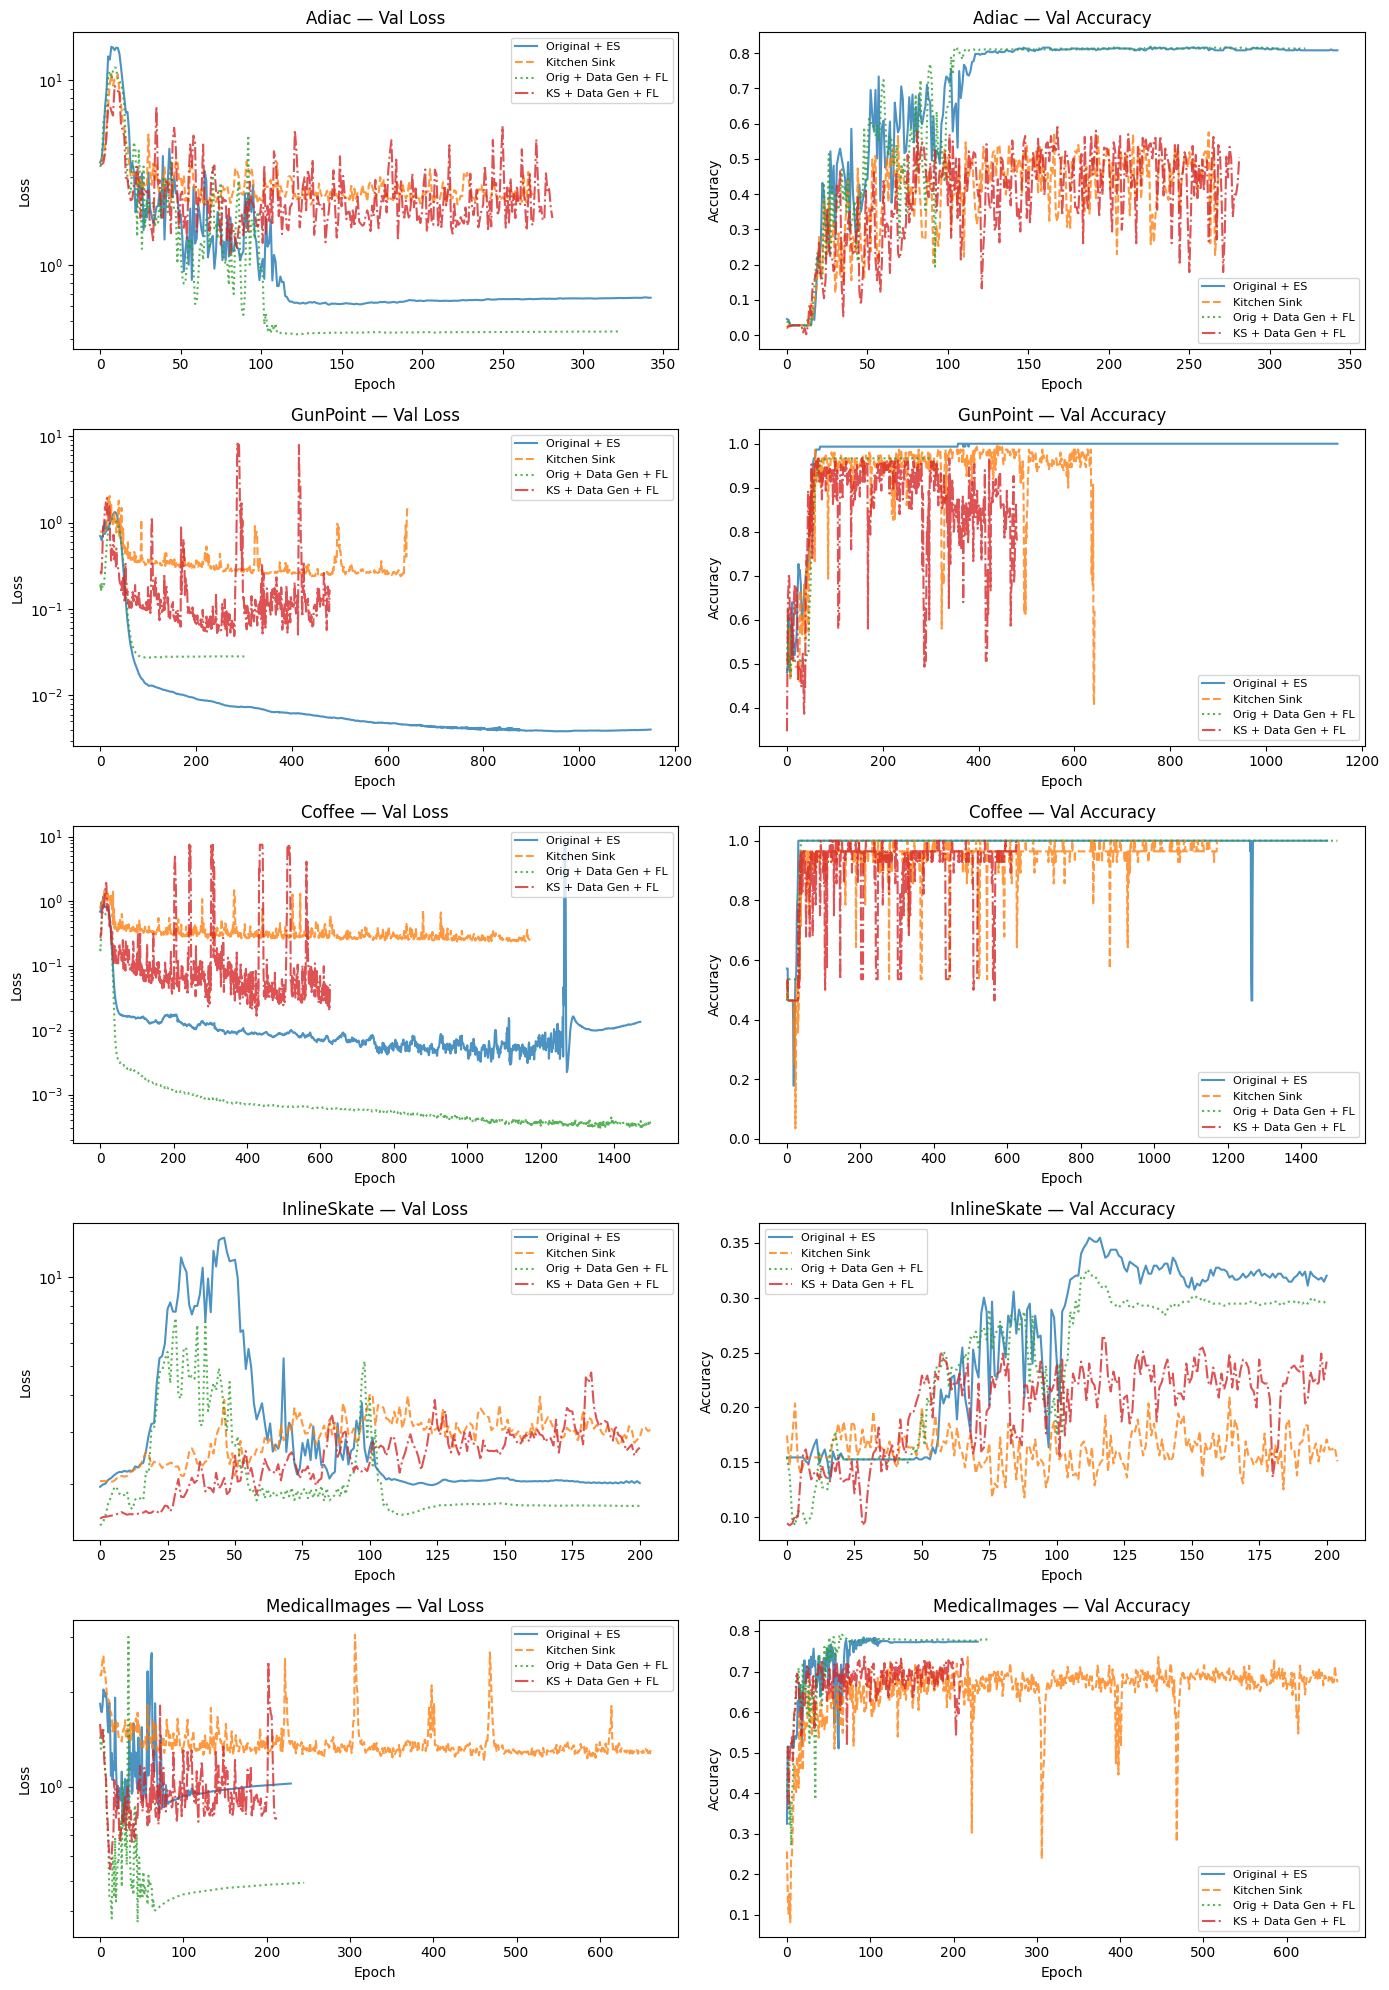

In [25]:
# Training curves — 4-experiment comparison (seed 0)
fig, axes = plt.subplots(len(CONFIG['datasets']), 2,
                         figsize=(14, 4 * len(CONFIG['datasets'])))
if len(CONFIG['datasets']) == 1:
    axes = axes.reshape(1, -1)

for row, ds in enumerate(CONFIG['datasets']):
    h_es = earlystop_results[ds]['all_results'][0]['history']
    h_ks = kitchen_sink_results[ds]['all_results'][0]['history']
    h_df = datagen_focal_results[ds]['all_results'][0]['history']
    h_kd = kitchen_sink_datagen_results[ds]['all_results'][0]['history']

    ax = axes[row, 0]
    ax.plot(h_es['val_loss'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_loss'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_loss'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_loss'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Loss'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss'); ax.set_yscale('log'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(h_es['val_accuracy'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_accuracy'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_accuracy'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_accuracy'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Accuracy'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_training_curves.png'), dpi=150)
plt.show()


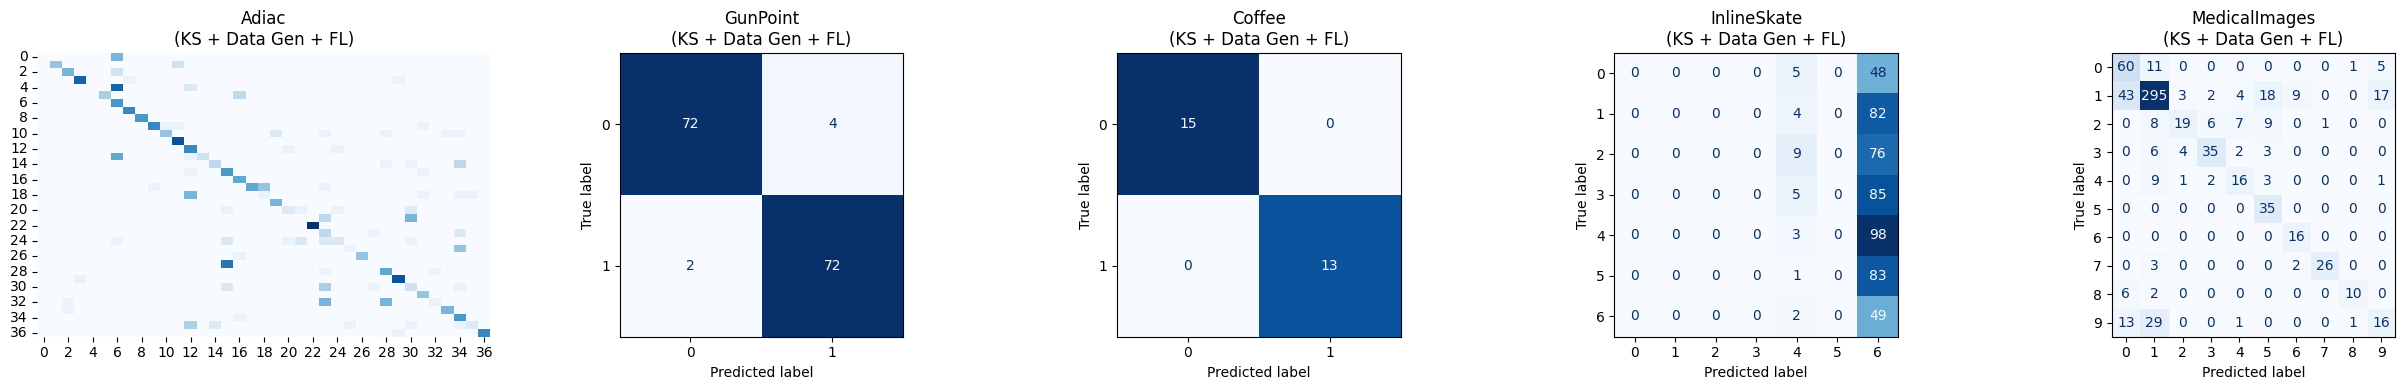

In [26]:
# Confusion matrices (Kitchen Sink + Data Gen + FL, seed 0)
n_ds = len(CONFIG['datasets'])
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1: axes = [axes]
for i, ds in enumerate(CONFIG['datasets']):
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    cm = confusion_matrix(best_run['y_test'], best_run['y_pred'])
    nb_classes = data_store[ds]['nb_classes']
    if nb_classes > 10:
        sns.heatmap(cm, ax=axes[i], cmap='Blues', cbar=False)
    else:
        ConfusionMatrixDisplay(cm).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{ds}\n(KS + Data Gen + FL)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_confusion_matrices.png'), dpi=150)
plt.show()


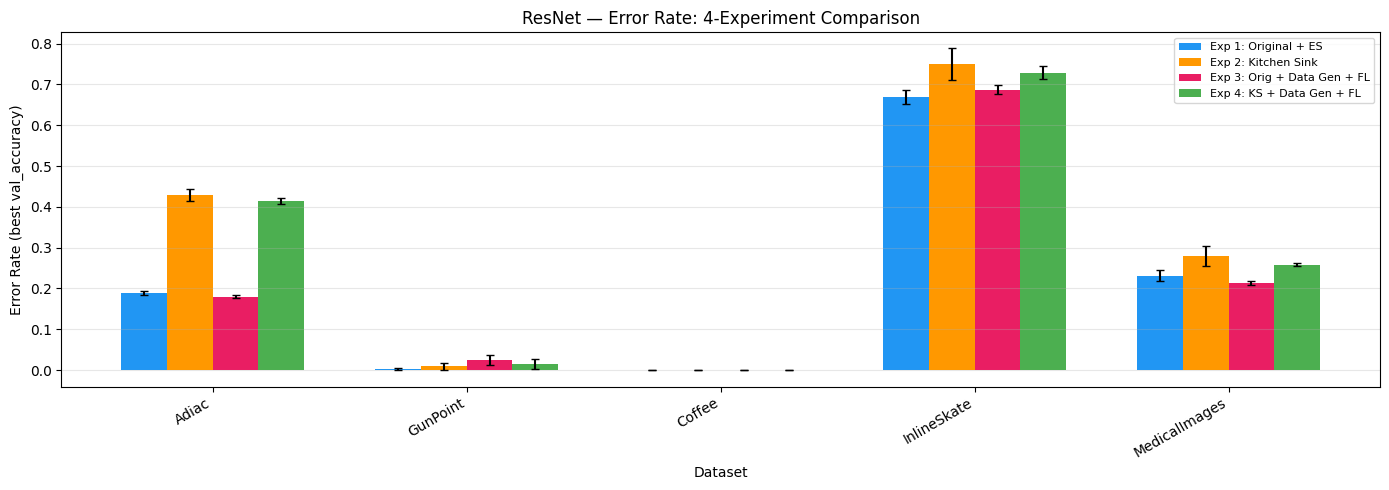

In [27]:
# Bar chart: 4-experiment comparison
datasets = CONFIG['datasets']
x_pos = np.arange(len(datasets))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
labels  = ['Exp 1: Original + ES', 'Exp 2: Kitchen Sink',
           'Exp 3: Orig + Data Gen + FL', 'Exp 4: KS + Data Gen + FL']
colours = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50']
errors_list = [
    [earlystop_results[ds]['mean_best_val_error']            for ds in datasets],
    [kitchen_sink_results[ds]['mean_best_val_error']         for ds in datasets],
    [datagen_focal_results[ds]['mean_best_val_error']        for ds in datasets],
    [kitchen_sink_datagen_results[ds]['mean_best_val_error'] for ds in datasets],
]
yerrs_list = [
    [earlystop_results[ds]['std_best_val_error']             for ds in datasets],
    [kitchen_sink_results[ds]['std_best_val_error']          for ds in datasets],
    [datagen_focal_results[ds]['std_best_val_error']         for ds in datasets],
    [kitchen_sink_datagen_results[ds]['std_best_val_error']  for ds in datasets],
]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (label, colour, errs, yerrs) in enumerate(zip(labels, colours, errors_list, yerrs_list)):
    ax.bar(x_pos + offsets[i] * width, errs, width,
           label=label, color=colour, yerr=yerrs, capsize=3)

ax.set_xlabel('Dataset'); ax.set_ylabel('Error Rate (best val_accuracy)')
ax.set_title('ResNet — Error Rate: 4-Experiment Comparison')
ax.set_xticks(x_pos); ax.set_xticklabels(datasets, rotation=30, ha='right')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'resnet_barchart.png'), dpi=150)
plt.show()


### Per-Class Metrics, MPCE & Save

In [28]:
# Classification reports (Kitchen Sink + Data Gen + FL, seed 0)
for ds in CONFIG['datasets']:
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    print(f"\n{'='*60}")
    print(f"  Classification Report: {ds} (KS + Data Gen + FL ResNet)")
    print(f"{'='*60}")
    print(classification_report(best_run['y_test'], best_run['y_pred'],
                                digits=3, zero_division=0))



  Classification Report: Adiac (KS + Data Gen + FL ResNet)
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      1.000     0.667     0.800         9
           2      0.778     0.700     0.737        10
           3      0.923     0.857     0.889        14
           4      0.000     0.000     0.000        14
           5      1.000     0.556     0.714         9
           6      0.225     1.000     0.367         9
           7      0.909     1.000     0.952        10
           8      1.000     1.000     1.000         9
           9      0.909     0.769     0.833        13
          10      0.857     0.500     0.632        12
          11      0.765     1.000     0.867        13
          12      0.385     0.833     0.526        12
          13      1.000     0.250     0.400        12
          14      0.667     0.400     0.500        10
          15      0.360     0.818     0.500        11
          16      0.5

In [29]:
# MPCE (paper Equation 4)
def compute_mpce(results_dict, key='mean_error'):
    pce = []
    for ds in CONFIG['datasets']:
        error = results_dict[ds][key]
        pce.append(error / data_store[ds]['nb_classes'])
    return np.mean(pce)

mpce_paper = np.mean([PAPER_RESNET_ERRORS[ds] / data_store[ds]['nb_classes']
                      for ds in CONFIG['datasets']])

print("Mean Per-Class Error (MPCE) — lower is better\n")
print(f"  Paper (published)         : {mpce_paper:.5f}")
for vn in [k for k in all_experiments if k != 'Paper']:
    mpce_r = compute_mpce(all_experiments[vn], 'mean_error')
    mpce_b = compute_mpce(all_experiments[vn], 'mean_best_val_error')
    print(f"  {vn:25s}: {mpce_r:.5f} (restored)  {mpce_b:.5f} (best val_acc)")

Mean Per-Class Error (MPCE) — lower is better

  Paper (published)         : 0.02434
  Original + ES            : 0.03071 (restored)  0.02499 (best val_acc)
  Kitchen Sink             : 0.03438 (restored)  0.03023 (best val_acc)
  Original + Data Gen + FL : 0.03227 (restored)  0.02733 (best val_acc)
  KS + Data Gen + FL       : 0.03626 (restored)  0.02979 (best val_acc)


In [30]:
# Save results
rows = []
for ds in CONFIG['datasets']:
    row = {
        'Dataset': ds,
        'Classes': data_store[ds]['nb_classes'],
        'Train_N': data_store[ds]['x_train'].shape[0],
        'Test_N': data_store[ds]['x_test'].shape[0],
        'Length': data_store[ds]['x_train'].shape[1],
        'Paper_Error': PAPER_RESNET_ERRORS.get(ds, None),
    }
    for en, ed in all_experiments.items():
        if en == 'Paper': continue
        safe = en.replace('+', '').replace(' ', '_').strip('_')
        row[f'{safe}_Error'] = ed[ds]['mean_error']
        row[f'{safe}_Std']   = ed[ds]['std_error']
        row[f'{safe}_BestValErr'] = ed[ds]['mean_best_val_error']
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = os.path.join(CONFIG['output_dir'], 'resnet_results.csv')
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}\n")
df_d = df.copy()
df_d[df_d.select_dtypes('float').columns] = df_d.select_dtypes('float').round(4)
print(df_d.set_index('Dataset').T.to_string())

Results saved to results/resnet_results.csv

Dataset                               Adiac  GunPoint  Coffee  InlineSkate  MedicalImages
Classes                             37.0000    2.0000     2.0       7.0000        10.0000
Train_N                            390.0000   50.0000    28.0     100.0000       381.0000
Test_N                             391.0000  150.0000    28.0     550.0000       760.0000
Length                             176.0000  150.0000   286.0    1882.0000        99.0000
Paper_Error                          0.1740    0.0070     0.0       0.6350         0.2280
Original__ES_Error                   0.2020    0.0044     0.0       0.8303         0.2724
Original__ES_Std                     0.0096    0.0063     0.0       0.0177         0.0112
Original__ES_BestValErr              0.1884    0.0022     0.0       0.6691         0.2316
Kitchen_Sink_Error                   0.4518    0.0178     0.0       0.8418         0.3053
Kitchen_Sink_Std                     0.0189    0.0113  

In [26]:
# Save all ResNet results to Google Drive and download locally

from google.colab import drive
drive.mount('/content/drive')

drive_dir = '/content/drive/MyDrive/TSC_Results/ResNet'
os.makedirs(drive_dir, exist_ok=True)

# Copy results/ to Drive
import shutil
local_results = CONFIG['output_dir']

for fname in os.listdir(local_results):
    src = os.path.join(local_results, fname)
    dst = os.path.join(drive_dir, fname)
    shutil.copy2(src, dst)
    print(f"  → Drive: {dst}")

# Save full results as pickle
import pickle

save_data = {
    'earlystop_results': earlystop_results,
    'kitchen_sink_results': kitchen_sink_results,
        'datagen_focal_results': datagen_focal_results,
        'kitchen_sink_datagen_results': kitchen_sink_datagen_results,
    'all_experiments': all_experiments,
    'CONFIG': CONFIG,
    'PAPER_RESNET_ERRORS': PAPER_RESNET_ERRORS,
}
pkl_path = os.path.join(drive_dir, 'resnet_all_results.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f"  → Drive: {pkl_path}")

print(f"\nAll files saved to Google Drive: {drive_dir}")

# Download to local machine
from google.colab import files
zip_path = '/content/resnet_results.zip'
shutil.make_archive('/content/resnet_results', 'zip', local_results)
files.download(zip_path)
print("Download started — check your browser's download bar.")

Mounted at /content/drive
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_confusion_matrices.png
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_results.csv
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_training_curves.png
  → Drive: /content/drive/MyDrive/TSC_Results/ResNet/resnet_all_results.pkl

All files saved to Google Drive: /content/drive/MyDrive/TSC_Results/ResNet


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — check your browser's download bar.


### Summary of Findings

#### Architecture Fixes
- Conv2D→Conv1D rewrite matches the paper's "1-D kernels" description
- Parameterised residual blocks replace 90+ lines of copy-paste
- Removed spurious input BatchNorm not in the paper

#### Improvements Applied
- **Early stopping on val_loss** — critical for ResNet which the paper says overfits easily
- **Multi-seed train/evaluation** - running the process over three seeds
- **SpatialDropout1D** — drops entire feature map channels, appropriate for conv layers
- **L2 regularisation** — continuous weight decay on conv kernels
- **Gradient clipping** — stabilises training on long series (InlineSkate, 1882 timesteps)
- **Label smoothing** — reduces overconfident predictions
- **Class weighting** — addresses MedicalImages imbalance
- **Jitter + scaling augmentation** — input-space regularisation
- **Mixup** — virtual training sample creation via interpolation
- **GPU/MPS auto-detection with mixed precision** — meaningful speedup for conv-heavy ResNet